# Notebook 09 — Fatigue via Acceleration/Deceleration & Distance

Analyzes **all players** across all games/periods using **actual shifts** as the unit of observation
(not arbitrary time bins). This avoids bin-bridging artifacts and gives each data point a clean
semantic meaning: one shift = one on-ice effort unit.

## Two-Component Fatigue Framework

| Component | Question | Unit |
|-----------|----------|------|
| **Within-period slope** | Does each successive shift produce less? | OLS slope of metric vs shift start time within the period |
| **Period-to-period level** | Does each period start from a lower baseline? | Mean metric per period, compared across periods |

## Metrics
| Metric | Fatigue signal |
|--------|----------------|
| `dist_ft_per_min` | Primary — most stable; captures overall work rate |
| `accels_per_min` | Burst capacity — drops earlier than speed |
| `decels_per_min` | Linked to reacceleration capacity |
| `mean_burst_intensity` | Mean \|accel\| for bursts above threshold — intensity decay |

**Pipeline**
1. Load tracking; verify `accel_mph_s` is baked in  
2. Filter to skaters; define constants  
3. Load shifts → compute per-shift metrics (tracking frames joined to shift windows)  
4. Population overview: shift-rank profiles + period-level medians  
5. Within-period OLS slopes — distribution + per-period breakdown  
6. Two-component fatigue space: within-period slope vs period-level accumulation  
7. H1 survivor bias diagnostic — the sharper test  
8. Individual player deep-dive  


## 1 — Imports & Data

In [14]:
import sys, warnings, importlib
from pathlib import Path
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import utils
importlib.reload(utils)
from utils import load_tracking, X, Y

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = Path('../data')

tracking = load_tracking(str(DATA_DIR / 'tracking.parquet'))

print('Tracking rows:', len(tracking))
print('Skater rows :', (tracking['Player or Puck'] == 'Player').sum())
print('Speed col present:', 'speed_mph_savgol' in tracking.columns)
print('Accel col present:', 'accel_mph_s' in tracking.columns)


Tracking rows: 8401602
Skater rows : 7441848
Speed col present: True
Accel col present: True


## 2 — Constants & Skater Setup

`accel_mph_s` should already be baked into `tracking.parquet` (run `preprocess.py` if missing).
All shift-based analysis uses `MIN_FRAMES` only to filter shift windows with insufficient tracking coverage
— it is **not** used for arbitrary time-binning.


In [15]:
FPS          = 30.0
ACCEL_THRESH  = 1.5      # mph/s ≈ 0.67 m/s² — lower burst threshold
ACCEL_THRESH2 = 4.474    # mph/s ≈ 2.0  m/s² — high-intensity burst threshold
MIN_FRAMES   = 300       # ~10 s — minimum tracking frames to include a shift window
DIST_CONV    = 5280 / 3600 / FPS   # 1 mph * DIST_CONV = ft per frame

METRICS = [
    ('dist_ft_per_min',      'Distance (ft/min)',                    '#1565C0'),
    ('accels_per_min',       'Accelerations >0.67 m/s² (bursts/min)', '#B71C1C'),
    ('decels_per_min',       'Decelerations >0.67 m/s² (bursts/min)', '#2E7D32'),
    ('accels_per_min2',      'Accelerations >2 m/s² (bursts/min)',    '#E91E63'),
    ('decels_per_min2',      'Decelerations >2 m/s² (bursts/min)',    '#00838F'),
    ('mean_burst_intensity', 'Burst intensity (mph/s)',               '#E65100'),
]
PERIOD_COLORS  = {1: '#1565C0', 2: '#B71C1C', 3: '#2E7D32'}
PERIOD_BREAKS_MIN = [20, 40]

# ── Skater frames only (exclude goalies with non-numeric jerseys) ─────────────
sk = tracking[tracking['Player or Puck'] == 'Player'].copy()
sk = sk[sk['Player Jersey Number'].astype(str).str.match(r'^\d+$')]
sk = sk.sort_values(['Game', 'Period_int', 'Player Jersey Number', 'frame_id'])

if 'elapsed_in_period_s' not in sk.columns:
    sk['elapsed_in_period_s'] = sk['Elapsed_s'] - (sk['Period_int'] - 1) * 1200

# Verify accel is present
accel_clean = sk['accel_mph_s'].dropna()
print(f'Accel non-null rows: {len(accel_clean):,}')
print(f'Accel stats: mean={accel_clean.mean():.3f}  std={accel_clean.std():.3f}  '
      f'p5={accel_clean.quantile(0.05):.2f}  p95={accel_clean.quantile(0.95):.2f} mph/s')
print(f'\nBurst thresholds: {ACCEL_THRESH} mph/s ≈ 0.67 m/s²  |  '
      f'{ACCEL_THRESH2} mph/s ≈ 2.0 m/s²')


Accel non-null rows: 6,394,419
Accel stats: mean=0.231  std=11.568  p5=-17.03  p95=18.15 mph/s

Burst thresholds: 1.5 mph/s ≈ 0.67 m/s²  |  4.474 mph/s ≈ 2.0 m/s²


## 3 — Load Shifts & Compute Per-Shift Metrics

Each row in `shift_df` is one skater shift with ≥`MIN_FRAMES` tracking frames. Metrics are
**rate-normalised per minute of actual ice time** so short shifts aren't penalised.

The shift record determines the window; tracking frames within that window are aggregated.
No arbitrary binning — each data point has a real start/end boundary from the shift log.


In [16]:
def parse_clock(clock_str):
    """'MM:SS' countdown clock → elapsed seconds within period (0 = period start)."""
    parts = str(clock_str).strip().split(':')
    return 1200 - (int(parts[0]) * 60 + int(parts[1]))

# ── Load and clean shifts ─────────────────────────────────────────────────────
shifts_raw = pd.read_parquet(DATA_DIR / 'shifts.parquet')
shifts_sk  = shifts_raw.copy()
shifts_sk  = shifts_sk[shifts_sk['Player_Id'].notna()]
shifts_sk  = shifts_sk[shifts_sk['Player_Id'].astype(str).str.match(r'^\d+$')]
shifts_sk  = shifts_sk[shifts_sk['period'].isin([1, 2, 3])].copy()

shifts_sk['Game']          = shifts_sk['Date'] + ' ' + shifts_sk['Home_Team'] + ' @ ' + shifts_sk['Away_Team']
shifts_sk['Period_int']    = shifts_sk['period'].astype(int)
shifts_sk['Player_Id']     = shifts_sk['Player_Id'].astype(str)
shifts_sk['shift_start_s'] = shifts_sk['start_clock'].apply(parse_clock)
shifts_sk['shift_end_s']   = shifts_sk['end_clock'].apply(parse_clock)
shifts_sk = shifts_sk[
    (shifts_sk['shift_end_s'] > shifts_sk['shift_start_s']) &
    (shifts_sk['shift_start_s'] >= 0) &
    (shifts_sk['shift_end_s'] <= 1200)
]

sh_len = shifts_sk['shift_end_s'] - shifts_sk['shift_start_s']
print(f'Skater shifts (P1–P3): {len(shifts_sk):,}   '
      f'mean={sh_len.mean():.0f}s  median={sh_len.median():.0f}s')

# ── Fast per-player tracking lookup ──────────────────────────────────────────
sk_player_idx = {}
for (game, period, pid), grp in sk.groupby(
        ['Game', 'Period_int', 'Player Jersey Number'], sort=False):
    sk_player_idx[(game, period, str(pid))] = grp.sort_values('frame_id')

print(f'Tracking groups (game × period × player): {len(sk_player_idx):,}')

# ── Compute per-shift metrics ─────────────────────────────────────────────────
shift_rows = []
for _, sh in shifts_sk.iterrows():
    key = (sh['Game'], sh['Period_int'], sh['Player_Id'])
    tr  = sk_player_idx.get(key)
    if tr is None or tr.empty:
        continue
    window = tr[
        (tr['elapsed_in_period_s'] >= sh['shift_start_s']) &
        (tr['elapsed_in_period_s'] <= sh['shift_end_s'])
    ]
    n = len(window)
    if n < MIN_FRAMES:
        continue

    spd   = window['speed_mph_savgol'].to_numpy(dtype=float)
    acc   = window['accel_mph_s'].to_numpy(dtype=float)
    v_spd = spd[~np.isnan(spd)]
    v_acc = acc[~np.isnan(acc)]
    ice_min = n / FPS / 60
    dist_ft = np.nansum(v_spd) * DIST_CONV
    n_ac    = (v_acc >  ACCEL_THRESH).sum()
    n_dc    = (v_acc < -ACCEL_THRESH).sum()
    n_ac2   = (v_acc >  ACCEL_THRESH2).sum()
    n_dc2   = (v_acc < -ACCEL_THRESH2).sum()
    hi      = np.abs(v_acc[np.abs(v_acc) > ACCEL_THRESH])

    shift_rows.append({
        'Game'               : sh['Game'],
        'Period_int'         : sh['Period_int'],
        'Player_Id'          : sh['Player_Id'],
        'shift_number'       : sh['shift_number'],
        'shift_start_s'      : sh['shift_start_s'],
        'shift_start_min'    : sh['shift_start_s'] / 60,
        'n_frames'           : n,
        'ice_min'            : ice_min,
        'dist_ft_per_min'    : dist_ft / ice_min if ice_min > 0 else np.nan,
        'accels_per_min'     : n_ac    / ice_min if ice_min > 0 else np.nan,
        'decels_per_min'     : n_dc    / ice_min if ice_min > 0 else np.nan,
        'accels_per_min2'    : n_ac2   / ice_min if ice_min > 0 else np.nan,
        'decels_per_min2'    : n_dc2   / ice_min if ice_min > 0 else np.nan,
        'mean_burst_intensity': hi.mean() if len(hi) > 0 else np.nan,
    })

shift_df = pd.DataFrame(shift_rows)
print(f'\nShifts with ≥{MIN_FRAMES} frames ({MIN_FRAMES/FPS:.0f}s): {len(shift_df):,}')
print(f'Players: {shift_df["Player_Id"].nunique()}   Games: {shift_df["Game"].nunique()}')
print('\nMetric summary:')
print(shift_df[['dist_ft_per_min','accels_per_min','decels_per_min',
                'accels_per_min2','decels_per_min2','mean_burst_intensity']]
      .describe().round(2).to_string())


Skater shifts (P1–P3): 7,589   mean=46s  median=44s
Tracking groups (game × period × player): 981

Shifts with ≥300 frames (10s): 6,218
Players: 76   Games: 10

Metric summary:
       dist_ft_per_min  accels_per_min  decels_per_min  accels_per_min2  decels_per_min2  mean_burst_intensity
count          6218.00         6218.00         6218.00          6218.00          6218.00               6199.00
mean            863.78          724.08          726.09           512.29           500.68                  9.46
std             166.72          128.42          128.98           101.89           100.46                  1.58
min             297.72            0.00            0.00             0.00             0.00                  4.95
25%             757.49          708.35          714.81           477.42           467.21                  8.52
50%             867.31          753.19          757.00           526.24           516.62                  9.30
75%             976.21          788.82        

## 4 — Population Overview

Two panels:
1. **Shift-rank profile by period** — median metric at rank 1, 2, 3… shift within the period. If fatigue
   is real within a period, this should slope down. P1/P2/P3 overlaid to see if the pattern holds
   across periods.
2. **Period-to-period level** — each player-game as a spaghetti line across periods; population median
   as bold overlay. This is the between-period (cumulative game fatigue) signal.


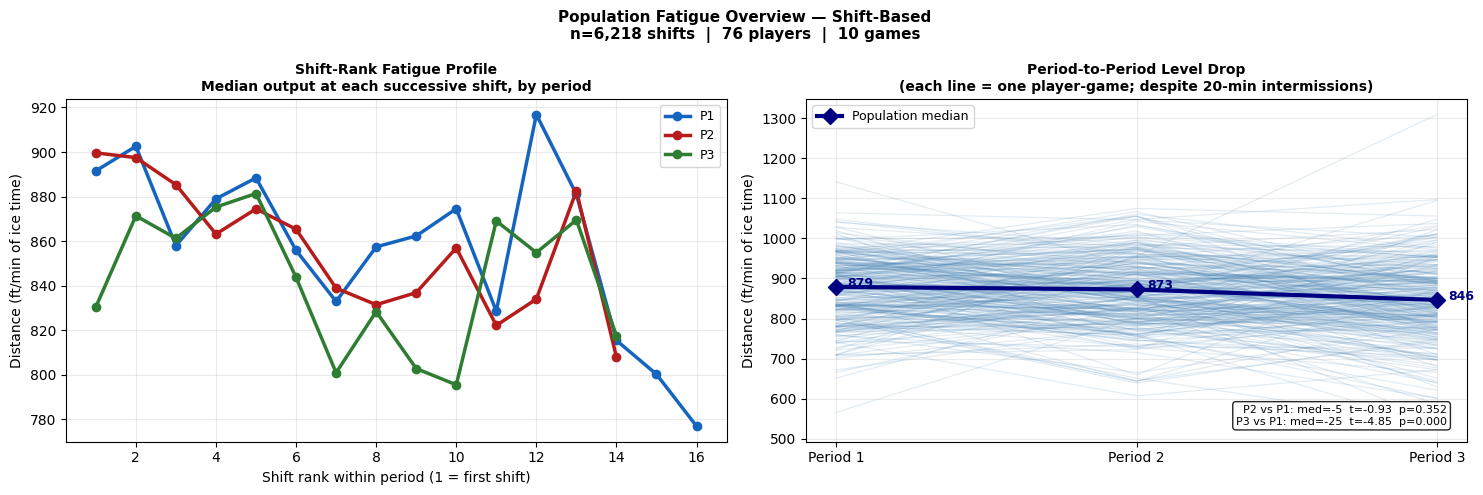

In [17]:
PRIMARY       = 'dist_ft_per_min'
PRIMARY_LABEL = 'Distance (ft/min of ice time)'
MIN_SHIFTS_PER_PERIOD = 2

# ── Rank shifts within each player-game-period ────────────────────────────────
shift_df['shift_rank'] = (
    shift_df
    .groupby(['Game', 'Player_Id', 'Period_int'])['shift_start_min']
    .rank(method='first')
    .astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: shift-rank median by period
ax = axes[0]
for period, color in PERIOD_COLORS.items():
    sub      = shift_df[shift_df['Period_int'] == period]
    rank_med = sub.groupby('shift_rank')[PRIMARY].median()
    rank_n   = sub.groupby('shift_rank')[PRIMARY].count()
    rank_med = rank_med[rank_n >= 10]
    if rank_med.empty:
        continue
    ax.plot(rank_med.index, rank_med.values, color=color, lw=2.5,
            marker='o', markersize=6, label=f'P{period}')
ax.set_xlabel('Shift rank within period (1 = first shift)', fontsize=10)
ax.set_ylabel(PRIMARY_LABEL, fontsize=10)
ax.set_title('Shift-Rank Fatigue Profile\n'
             'Median output at each successive shift, by period',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

# Panel 2: period-to-period level (spaghetti + median)
# Compute per-period mean per player-game (from shift_df directly)
period_means = (
    shift_df
    .groupby(['Game', 'Player_Id', 'Period_int'])[PRIMARY]
    .mean()
    .reset_index(name='period_mean')
)
period_pivot = (
    period_means
    .pivot_table(index=['Game', 'Player_Id'], columns='Period_int',
                 values='period_mean', aggfunc='mean')
    .rename(columns={1: 'P1_mean', 2: 'P2_mean', 3: 'P3_mean'})
    .reset_index()
    .dropna(subset=['P1_mean', 'P2_mean', 'P3_mean'])
)

ax = axes[1]
for _, row in period_pivot.iterrows():
    ax.plot([1, 2, 3], [row['P1_mean'], row['P2_mean'], row['P3_mean']],
            color='steelblue', alpha=0.15, lw=0.9)
med_by_period = [
    period_means[period_means['Period_int'] == p]['period_mean'].median()
    for p in [1, 2, 3]
]
ax.plot([1, 2, 3], med_by_period, color='navy', lw=3, marker='D', markersize=8,
        label='Population median', zorder=5)
for x, y in zip([1, 2, 3], med_by_period):
    ax.annotate(f'{y:.0f}', (x, y), textcoords='offset points',
                xytext=(8, 0), fontsize=9, color='navy', fontweight='bold')

# t-tests for period drops
period_pivot['P2_drop'] = period_pivot['P2_mean'] - period_pivot['P1_mean']
period_pivot['P3_drop'] = period_pivot['P3_mean'] - period_pivot['P1_mean']
t_p2, p_p2 = stats.ttest_1samp(period_pivot['P2_drop'].dropna(), 0)
t_p3, p_p3 = stats.ttest_1samp(period_pivot['P3_drop'].dropna(), 0)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Period 1', 'Period 2', 'Period 3'], fontsize=10)
ax.set_ylabel(PRIMARY_LABEL, fontsize=10)
ax.set_title('Period-to-Period Level Drop\n'
             '(each line = one player-game; despite 20-min intermissions)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.text(0.97, 0.05,
        f'P2 vs P1: med={period_pivot["P2_drop"].median():+.0f}  t={t_p2:.2f}  p={p_p2:.3f}\n'
        f'P3 vs P1: med={period_pivot["P3_drop"].median():+.0f}  t={t_p3:.2f}  p={p_p3:.3f}',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

fig.suptitle(f'Population Fatigue Overview — Shift-Based\n'
             f'n={len(shift_df):,} shifts  |  {shift_df["Player_Id"].nunique()} players  |  '
             f'{shift_df["Game"].nunique()} games',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 5 — Within-Period Fatigue Slopes

Fit `metric ~ shift_start_min` (OLS) per **player-game-period**. The slope is the rate of
within-period decline for that player in that period.

- **Negative slope** = player produces less as the period goes on (fatigue signal)
- Distributions shown by period (P1/P2/P3 overlaid) to expose the P3 anomaly directly
- t-test against 0 for each period


Player-game-periods (≥2 shifts):  882  (P1=320  P2=318  P3=244)


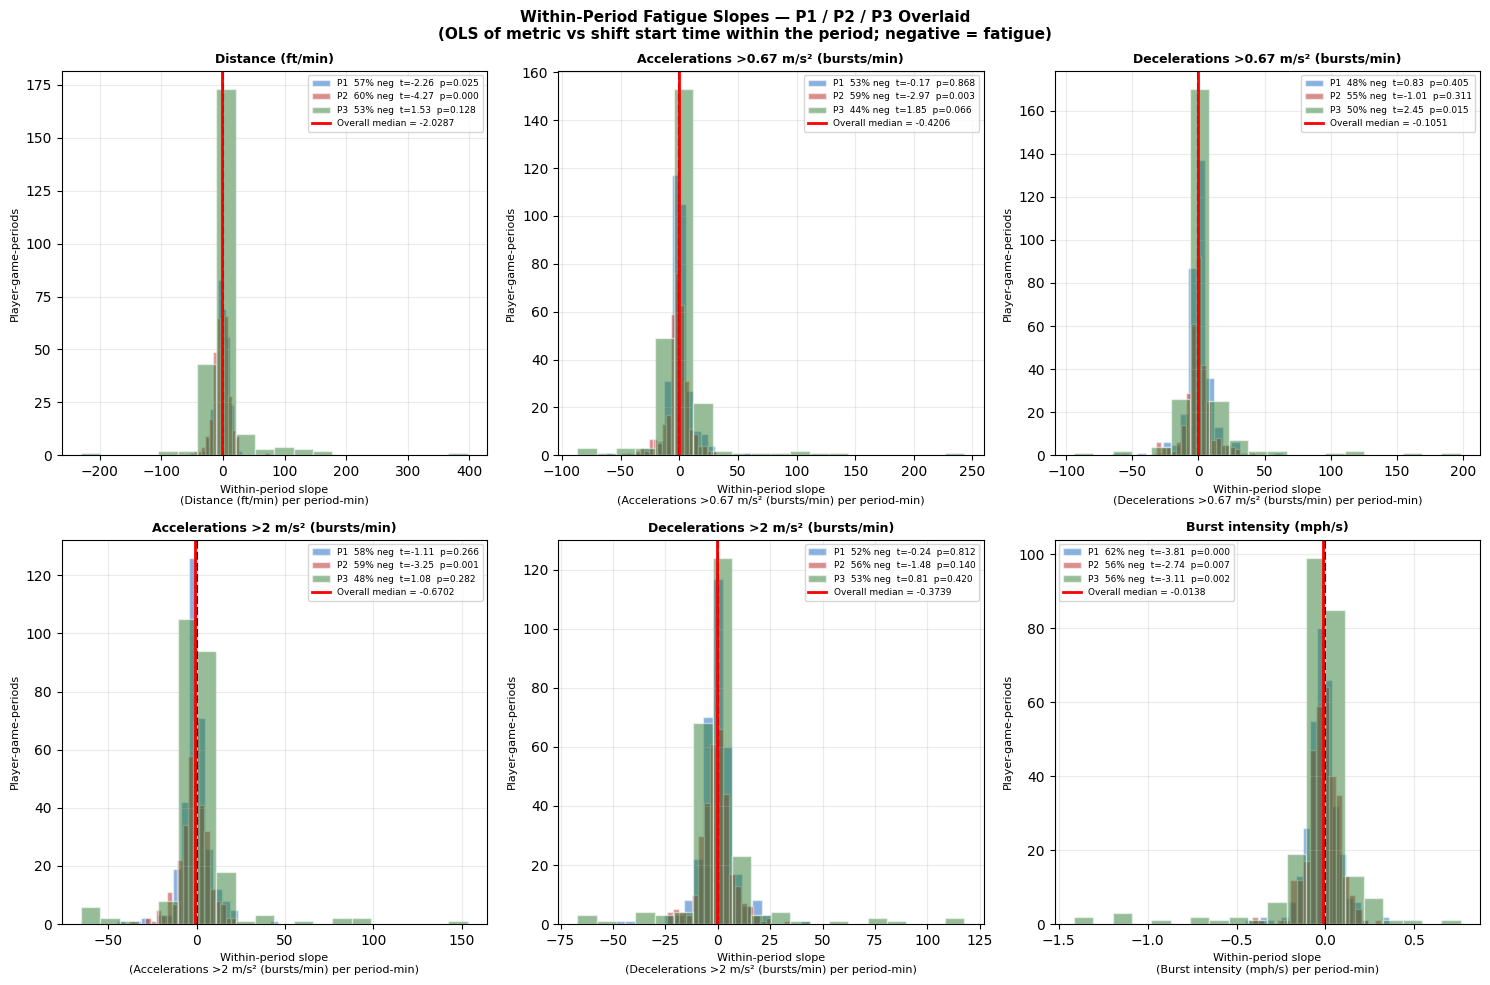


Within-period slope summary — all metrics:
Metric                          All med     P1 med     P2 med     P3 med     P1 p     P2 p     P3 p
Distance (ft/min)               -2.0287    -1.7451    -3.3018    -1.0705    0.025    0.000    0.128
Accelerations >0.67 m/s² (b     -0.4206    -0.4891    -1.2226    +0.9521    0.868    0.003    0.066
Decelerations >0.67 m/s² (b     -0.1051    +0.1200    -0.7015    +0.0395    0.405    0.311    0.015
Accelerations >2 m/s² (burs     -0.6702    -0.7554    -1.0274    +0.2320    0.266    0.001    0.282
Decelerations >2 m/s² (burs     -0.3739    -0.1831    -0.6007    -0.2555    0.812    0.140    0.420
Burst intensity (mph/s)         -0.0138    -0.0159    -0.0099    -0.0118    0.000    0.007    0.002


In [18]:
# ── OLS slope per player-game-period, for every metric ───────────────────────
within_rows = []
for (game, pid, period), grp in shift_df.groupby(['Game', 'Player_Id', 'Period_int']):
    grp = grp.sort_values('shift_start_min')
    grp_p = grp.dropna(subset=[PRIMARY])
    if len(grp_p) < MIN_SHIFTS_PER_PERIOD:
        continue
    row = {
        'Game'       : game,
        'Player_Id'  : pid,
        'Period_int' : period,
        'period_mean': grp_p[PRIMARY].mean(),
        'n_shifts'   : len(grp_p),
    }
    for col, *_ in METRICS:
        g = grp.dropna(subset=[col])
        if len(g) >= MIN_SHIFTS_PER_PERIOD:
            s, *_ = stats.linregress(g['shift_start_min'], g[col])
            row[f'slope_{col}'] = s
        else:
            row[f'slope_{col}'] = np.nan
    row['within_slope'] = row[f'slope_{PRIMARY}']   # kept for downstream cells
    within_rows.append(row)

within_df = pd.DataFrame(within_rows)
print(f'Player-game-periods (≥{MIN_SHIFTS_PER_PERIOD} shifts):  {len(within_df)}'
      f'  (P1={( within_df.Period_int==1 ).sum()}'
      f'  P2={( within_df.Period_int==2 ).sum()}'
      f'  P3={( within_df.Period_int==3 ).sum()})')

# ── Plot: slope histograms by period, all metrics ─────────────────────────────
n_metrics = len(METRICS)
ncols = 3
nrows = (n_metrics + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for ax, (col, label, color) in zip(axes, METRICS):
    slope_col = f'slope_{col}'
    for period, pc in PERIOD_COLORS.items():
        vals = within_df[within_df['Period_int'] == period][slope_col].dropna()
        t_p, p_p = stats.ttest_1samp(vals, 0)
        pct_neg = (vals < 0).mean() * 100
        ax.hist(vals, bins=20, alpha=0.50, color=pc, edgecolor='white',
                label=f'P{period}  {pct_neg:.0f}% neg  t={t_p:.2f}  p={p_p:.3f}')

    all_vals = within_df[slope_col].dropna()
    ax.axvline(0, color='black', lw=1.5, linestyle='--')
    ax.axvline(all_vals.median(), color='red', lw=2,
               label=f'Overall median = {all_vals.median():+.4f}')
    ax.set_xlabel(f'Within-period slope\n({label} per period-min)', fontsize=8)
    ax.set_ylabel('Player-game-periods', fontsize=8)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6.5)
    ax.grid(alpha=0.25)

for ax in axes[n_metrics:]:
    ax.set_visible(False)

fig.suptitle('Within-Period Fatigue Slopes — P1 / P2 / P3 Overlaid\n'
             '(OLS of metric vs shift start time within the period; negative = fatigue)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\nWithin-period slope summary — all metrics:')
print(f'{"Metric":<28}  {"All med":>9}  {"P1 med":>9}  {"P2 med":>9}  {"P3 med":>9}  '
      f'{"P1 p":>7}  {"P2 p":>7}  {"P3 p":>7}')
for col, label, _ in METRICS:
    slope_col = f'slope_{col}'
    all_med = within_df[slope_col].median()
    row_str = f'{label[:27]:<28}  {all_med:>+9.4f}'
    for period in [1, 2, 3]:
        vals = within_df[within_df['Period_int'] == period][slope_col].dropna()
        t_p, p_p = stats.ttest_1samp(vals, 0)
        row_str += f'  {vals.median():>+9.4f}'
    for period in [1, 2, 3]:
        vals = within_df[within_df['Period_int'] == period][slope_col].dropna()
        _, p_p = stats.ttest_1samp(vals, 0)
        row_str += f'  {p_p:>7.3f}'
    print(row_str)


## 6 — Two-Component Fatigue Space

Each player-game is placed in a 2D space:

- **X-axis**: average within-period slope (ft/min per period-min elapsed) — captures intra-period decline
- **Y-axis**: P3 mean − P1 mean — captures game-level accumulation despite intermission recovery

The four quadrants identify distinct fatigue archetypes. Correlation between components tells us
whether within-period fatigors also accumulate game fatigue, or whether these are independent traits.


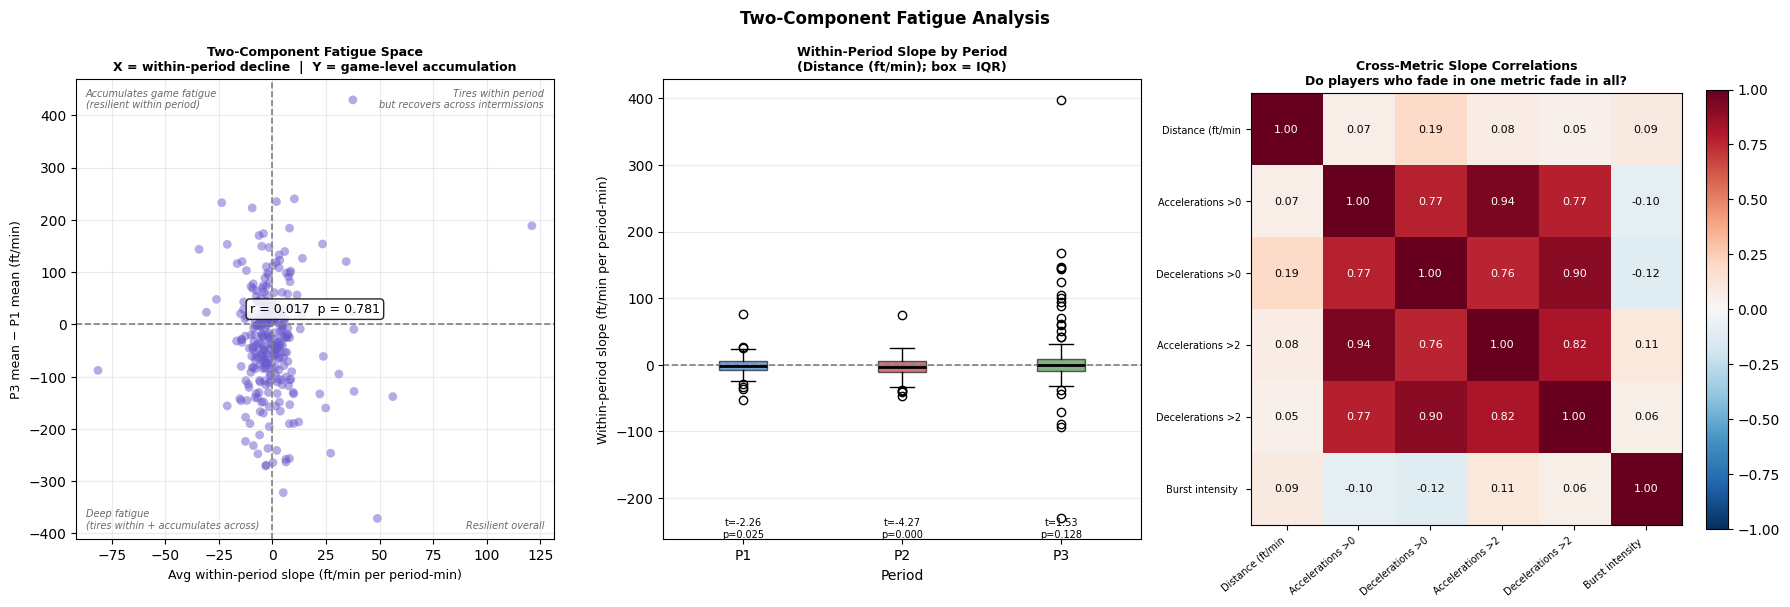


Player-games in combined space: 285
% with negative avg within-slope (dist): 59%
% with negative P3 drop:                 62%


In [19]:
avg_slope = (within_df.groupby(['Game', 'Player_Id'])['within_slope']
             .mean().reset_index(name='avg_within_slope'))
combined  = period_pivot.merge(avg_slope, on=['Game', 'Player_Id'])

# Add per-metric avg slopes to combined for cross-metric heatmap
for col, *_ in METRICS:
    slope_col = f'slope_{col}'
    avg = (within_df.groupby(['Game', 'Player_Id'])[slope_col]
           .mean().reset_index(name=f'avg_{slope_col}'))
    combined = combined.merge(avg, on=['Game', 'Player_Id'], how='left')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: two-component scatter (PRIMARY)
ax = axes[0]
ax.scatter(combined['avg_within_slope'], combined['P3_drop'],
           alpha=0.5, s=40, color='slateblue', edgecolors='none')
ax.axhline(0, color='grey', lw=1.2, linestyle='--')
ax.axvline(0, color='grey', lw=1.2, linestyle='--')
kw = dict(fontsize=7, color='dimgrey', style='italic')
ax.text(0.98, 0.98, 'Tires within period\nbut recovers across intermissions',
        ha='right', va='top',    transform=ax.transAxes, **kw)
ax.text(0.02, 0.98, 'Accumulates game fatigue\n(resilient within period)',
        ha='left',  va='top',    transform=ax.transAxes, **kw)
ax.text(0.98, 0.02, 'Resilient overall',
        ha='right', va='bottom', transform=ax.transAxes, **kw)
ax.text(0.02, 0.02, 'Deep fatigue\n(tires within + accumulates across)',
        ha='left',  va='bottom', transform=ax.transAxes, **kw)
if len(combined) >= 5:
    r_c, p_c = stats.pearsonr(combined['avg_within_slope'].dropna(),
                               combined['P3_drop'].dropna())
    ax.text(0.5, 0.5, f'r = {r_c:.3f}  p = {p_c:.3f}',
            transform=ax.transAxes, ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.set_xlabel('Avg within-period slope (ft/min per period-min)', fontsize=9)
ax.set_ylabel('P3 mean − P1 mean (ft/min)', fontsize=9)
ax.set_title('Two-Component Fatigue Space\n'
             'X = within-period decline  |  Y = game-level accumulation',
             fontsize=9, fontweight='bold')
ax.grid(alpha=0.25)

# Panel 2: within slopes by period — box plots (PRIMARY)
ax = axes[1]
data_by_period = [
    within_df[within_df['Period_int'] == p]['within_slope'].dropna().values
    for p in [1, 2, 3]
]
bp = ax.boxplot(data_by_period, labels=['P1', 'P2', 'P3'],
                patch_artist=True, notch=False,
                medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], PERIOD_COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0, color='grey', lw=1.2, linestyle='--')
for i, vals in enumerate(data_by_period, 1):
    t_p, p_p = stats.ttest_1samp(vals, 0)
    ymin = ax.get_ylim()[0]
    ax.text(i, ymin, f't={t_p:.2f}\np={p_p:.3f}',
            ha='center', va='bottom', fontsize=7)
ax.set_xlabel('Period', fontsize=10)
ax.set_ylabel('Within-period slope (ft/min per period-min)', fontsize=9)
ax.set_title('Within-Period Slope by Period\n'
             f'({[l for _, l, _ in METRICS if _ == METRICS[0][2]][0]}; box = IQR)',
             fontsize=9, fontweight='bold')
ax.grid(alpha=0.25, axis='y')

# Panel 3: cross-metric slope correlation heatmap
ax = axes[2]
slope_avg_cols = [f'avg_slope_{col}' for col, *_ in METRICS]
corr_data = combined[slope_avg_cols].dropna()
corr_mat  = corr_data.corr()
short_labels = [l[:16] for _, l, _ in METRICS]
im = ax.imshow(corr_mat.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(METRICS)))
ax.set_yticks(range(len(METRICS)))
ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=7)
ax.set_yticklabels(short_labels, fontsize=7)
for i in range(len(METRICS)):
    for j in range(len(METRICS)):
        v = corr_mat.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(v) > 0.5 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Cross-Metric Slope Correlations\n'
             'Do players who fade in one metric fade in all?',
             fontsize=9, fontweight='bold')

fig.suptitle('Two-Component Fatigue Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nPlayer-games in combined space: {len(combined)}')
print(f'% with negative avg within-slope (dist): {(combined["avg_within_slope"] < 0).mean()*100:.0f}%')
print(f'% with negative P3 drop:                 {(combined["P3_drop"] < 0).mean()*100:.0f}%')


## 7 — H1: Survivor Bias — The Sharper Test

The naive H1 test (do P3-active players have a higher P1 *baseline*?) misses the real question:

> **Do players who show the steepest within-period fatigue in P1/P2 get fewer P3 shifts?**

If so, P3's "resilient" within-period slope is an artifact of compositional change, not true recovery.

**The test:**
- Compute the within-period slope in P1 and P2 for every player-game
- Split into P3-present vs P3-absent groups
- Compare their P1/P2 slopes — if P3-absent players had steeper negative slopes, survivor bias is confirmed


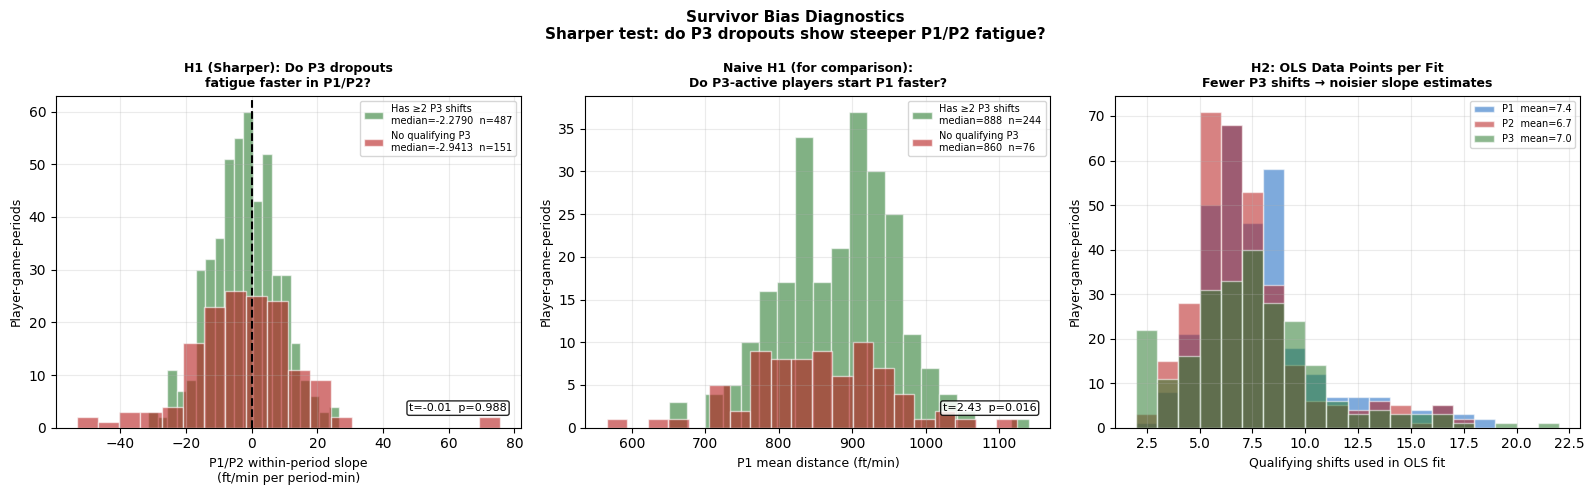


Survivor bias — sharper H1 across all metrics (P3-present vs P3-absent P1/P2 slopes):
Metric                        P3-present med  P3-absent med       t        p  Signal?
  Distance (ft/min)                   -2.2790        -2.9413   -0.01    0.988  
  Accelerations >0.67 m/s² (b         -0.6172        -1.2286    1.22    0.222  
  Decelerations >0.67 m/s² (b         -0.1886        +0.1172   -0.26    0.794  
  Accelerations >2 m/s² (burs         -0.7676        -1.8083    1.25    0.213  
  Decelerations >2 m/s² (burs         -0.2690        -0.7995    0.13    0.901  
  Burst intensity (mph/s)             -0.0125        -0.0182    2.28    0.023  ✓

Naive H1 — P1 baseline (dist): P3-present=888  P3-absent=860  t=2.43  p=0.016

If p < 0.05 for a metric → survivor bias explains the P3 anomaly for that metric.


In [20]:
p3_players = set(zip(
    within_df[within_df['Period_int'] == 3]['Game'],
    within_df[within_df['Period_int'] == 3]['Player_Id']
))

early_df = within_df[within_df['Period_int'].isin([1, 2])].copy()
early_df['in_p3'] = [
    (r['Game'], r['Player_Id']) in p3_players
    for _, r in early_df.iterrows()
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: P1+P2 within-slope by P3 presence (PRIMARY — most stable signal)
ax = axes[0]
for flag, label, color in [(True, 'Has ≥2 P3 shifts', '#2E7D32'),
                            (False, 'No qualifying P3', '#B71C1C')]:
    vals = early_df[early_df['in_p3'] == flag][f'slope_{PRIMARY}'].dropna()
    ax.hist(vals, bins=20, alpha=0.6, color=color, edgecolor='white',
            label=f'{label}\nmedian={vals.median():+.4f}  n={len(vals)}')
ax.axvline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('P1/P2 within-period slope\n(ft/min per period-min)', fontsize=9)
ax.set_ylabel('Player-game-periods', fontsize=9)
ax.set_title('H1 (Sharper): Do P3 dropouts\nfatigue faster in P1/P2?',
             fontsize=9, fontweight='bold')
g_in  = early_df[early_df['in_p3'] == True][f'slope_{PRIMARY}'].dropna()
g_out = early_df[early_df['in_p3'] == False][f'slope_{PRIMARY}'].dropna()
t_s, p_s = stats.ttest_ind(g_in, g_out)
ax.text(0.97, 0.05, f't={t_s:.2f}  p={p_s:.3f}',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85))
ax.legend(fontsize=7)
ax.grid(alpha=0.25)

# Panel 2: P1 baseline speed by P3 presence (naive H1)
ax = axes[1]
p1_all = within_df[within_df['Period_int'] == 1].copy()
p1_all['in_p3'] = [(r['Game'], r['Player_Id']) in p3_players for _, r in p1_all.iterrows()]
for flag, label, color in [(True, 'Has ≥2 P3 shifts', '#2E7D32'),
                            (False, 'No qualifying P3', '#B71C1C')]:
    vals = p1_all[p1_all['in_p3'] == flag]['period_mean'].dropna()
    ax.hist(vals, bins=20, alpha=0.6, color=color, edgecolor='white',
            label=f'{label}\nmedian={vals.median():.0f}  n={len(vals)}')
g1 = p1_all[p1_all['in_p3'] == True]['period_mean'].dropna()
g2 = p1_all[p1_all['in_p3'] == False]['period_mean'].dropna()
t_b, p_b = stats.ttest_ind(g1, g2)
ax.set_xlabel('P1 mean distance (ft/min)', fontsize=9)
ax.set_ylabel('Player-game-periods', fontsize=9)
ax.set_title('Naive H1 (for comparison):\nDo P3-active players start P1 faster?',
             fontsize=9, fontweight='bold')
ax.text(0.97, 0.05, f't={t_b:.2f}  p={p_b:.3f}',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85))
ax.legend(fontsize=7)
ax.grid(alpha=0.25)

# Panel 3: n_shifts by period (H2 — OLS data density)
ax = axes[2]
for period, color in PERIOD_COLORS.items():
    vals = within_df[within_df['Period_int'] == period]['n_shifts']
    ax.hist(vals, bins=range(2, int(vals.max()) + 2), alpha=0.55, color=color,
            edgecolor='white', label=f'P{period}  mean={vals.mean():.1f}')
ax.set_xlabel('Qualifying shifts used in OLS fit', fontsize=9)
ax.set_ylabel('Player-game-periods', fontsize=9)
ax.set_title('H2: OLS Data Points per Fit\n'
             'Fewer P3 shifts → noisier slope estimates',
             fontsize=9, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.25)

fig.suptitle('Survivor Bias Diagnostics\n'
             'Sharper test: do P3 dropouts show steeper P1/P2 fatigue?',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary: sharper H1 test across all metrics ───────────────────────────────
print('\nSurvivor bias — sharper H1 across all metrics (P3-present vs P3-absent P1/P2 slopes):')
print(f'{"Metric":<28}  {"P3-present med":>14}  {"P3-absent med":>13}  {"t":>6}  {"p":>7}  Signal?')
for col, label, _ in METRICS:
    sc    = f'slope_{col}'
    g_in  = early_df[early_df['in_p3'] == True][sc].dropna()
    g_out = early_df[early_df['in_p3'] == False][sc].dropna()
    if len(g_in) < 2 or len(g_out) < 2:
        continue
    t_m, p_m = stats.ttest_ind(g_in, g_out)
    sig = '✓' if p_m < 0.05 else ''
    print(f'  {label[:27]:<27}  {g_in.median():>+14.4f}  {g_out.median():>+13.4f}  '
          f'{t_m:>6.2f}  {p_m:>7.3f}  {sig}')

print(f'\nNaive H1 — P1 baseline (dist): P3-present={g1.median():.0f}  '
      f'P3-absent={g2.median():.0f}  t={t_b:.2f}  p={p_b:.3f}')
print(f'\nIf p < 0.05 for a metric → survivor bias explains the P3 anomaly for that metric.')


## 8 — Individual Player Deep-Dive

One player, all their shifts across all games and periods. Points are individual shifts; the trend
line is an OLS fit per period. Useful for sanity-checking, finding outlier players, and understanding
the within-period pattern at the individual level.

Set `TARGET_JERSEY` to any jersey number string; `TARGET_GAME` to a game string or `None` for all games.


Showing player #21  game: 2025-10-24 Team A @ Team B


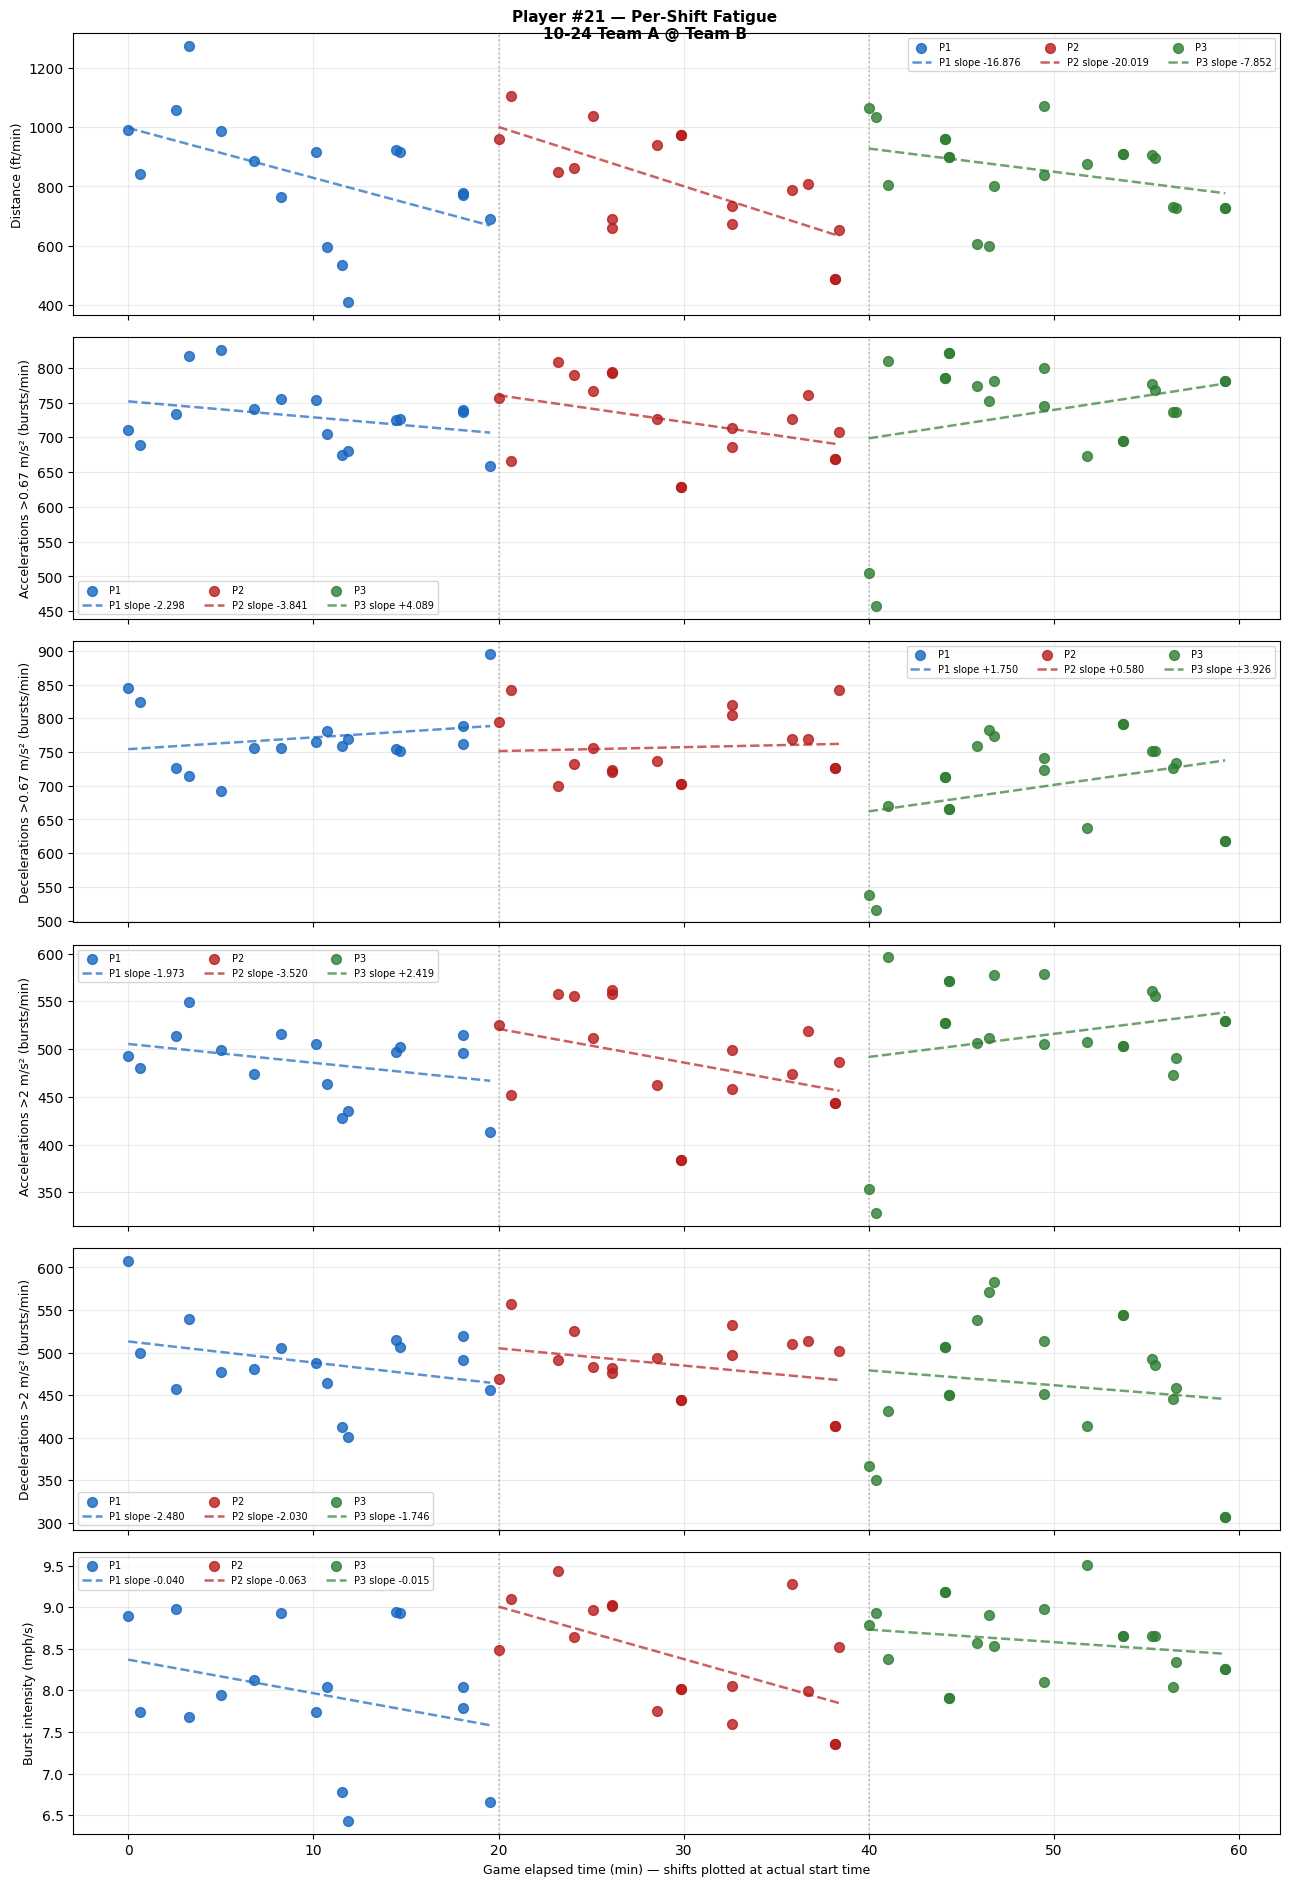

In [21]:
# ── Selection ─────────────────────────────────────────────────────────────────
# Default: player-game with the most qualifying shifts
target_row = (
    shift_df.groupby(['Player_Id', 'Game'])['n_frames']
    .count()
    .reset_index(name='n_shifts')
    .sort_values('n_shifts', ascending=False)
    .iloc[0]
)
TARGET_JERSEY = target_row['Player_Id']   # override: e.g. '22'
TARGET_GAME   = target_row['Game']        # override: None to show all games

print(f'Showing player #{TARGET_JERSEY}  game: {TARGET_GAME}')

sub = shift_df[shift_df['Player_Id'] == TARGET_JERSEY].copy()
if TARGET_GAME is not None:
    sub = sub[sub['Game'] == TARGET_GAME]

if sub.empty:
    print('No qualifying shifts for this player/game.')
else:
    fig, axes = plt.subplots(len(METRICS), 1, figsize=(13, 3.2 * len(METRICS)), sharex=True)
    game_short = TARGET_GAME.replace('2025-', '') if TARGET_GAME else 'all games'

    for ax, (col, label, color) in zip(axes, METRICS):
        sub_c = sub.dropna(subset=[col]).sort_values('shift_start_min')

        # Scatter points colored by period
        for period, pc in PERIOD_COLORS.items():
            p_sub = sub_c[sub_c['Period_int'] == period]
            ax.scatter(p_sub['shift_start_min'] + (period - 1) * 20,
                       p_sub[col], color=pc, s=50, alpha=0.8, zorder=3,
                       label=f'P{period}')
            # Per-period OLS trend
            if len(p_sub) >= 2:
                m, b = np.polyfit(p_sub['shift_start_min'], p_sub[col], 1)
                xs = np.linspace(p_sub['shift_start_min'].min(),
                                 p_sub['shift_start_min'].max(), 50)
                ax.plot(xs + (period - 1) * 20, m * xs + b,
                        color=pc, lw=1.8, linestyle='--', alpha=0.7,
                        label=f'P{period} slope {m:+.3f}')

        for pb in PERIOD_BREAKS_MIN:
            ax.axvline(pb, color='grey', lw=1.2, linestyle=':', alpha=0.5)

        ax.set_ylabel(label, fontsize=9)
        ax.legend(fontsize=7, ncol=3)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel('Game elapsed time (min) — shifts plotted at actual start time', fontsize=9)
    fig.suptitle(f'Player #{TARGET_JERSEY} — Per-Shift Fatigue\n{game_short}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
